<a href="https://colab.research.google.com/github/Zubair-471/GameForge3D/blob/master/notebooks/02_router_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GameForge3D — Phase 2: Asset Category Router (DistilBERT)

**FYP 2026-2027 | NUML Dept. of Computer Science**  
**Supervisor:** Ms. Tooba Sagheer

This notebook fine-tunes a **DistilBERT** model to classify text prompts into 4 categories:  
`Weapon` | `Vehicle` | `Prop` | `Creature`

**Steps:**
1. Mount Google Drive
2. Install Libraries
3. Load train / val splits
4. Tokenize dataset
5. Define DistilBERT model
6. Train with HuggingFace Trainer
7. Evaluate on val set
8. Save checkpoint to Drive
9. Quick inference test

## Step 1 — Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
DATA_DIR       = '/content/drive/MyDrive/GameForge3D/data'
CHECKPOINT_DIR = '/content/drive/MyDrive/GameForge3D/checkpoints/router'

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
print('Drive mounted.')
print(f'Data dir       : {DATA_DIR}')
print(f'Checkpoint dir : {CHECKPOINT_DIR}')

Mounted at /content/drive
Drive mounted.
Data dir       : /content/drive/MyDrive/GameForge3D/data
Checkpoint dir : /content/drive/MyDrive/GameForge3D/checkpoints/router


## Step 2 — Install Libraries

In [2]:
!pip install -q transformers datasets scikit-learn pandas torch
print('Libraries ready.')

Libraries ready.


## Step 3 — Load Train / Val Splits

These CSVs were saved to Drive in Phase 1.

In [3]:
import pandas as pd

df_train = pd.read_csv(f'{DATA_DIR}/router_train.csv')
df_val   = pd.read_csv(f'{DATA_DIR}/router_val.csv')

print(f'Train: {len(df_train)} samples')
print(f'Val  : {len(df_val)} samples')
print()
print('Train label distribution:')
print(df_train['label'].value_counts())

Train: 297 samples
Val  : 64 samples

Train label distribution:
label
Prop        77
Creature    77
Weapon      73
Vehicle     70
Name: count, dtype: int64


## Step 4 — Label Encoding & Tokenization

In [4]:
import torch
from torch.utils.data import Dataset
from transformers import DistilBertTokenizerFast

# --- Label map ---
LABELS    = ['Creature', 'Prop', 'Vehicle', 'Weapon']
LABEL2ID  = {l: i for i, l in enumerate(LABELS)}
ID2LABEL  = {i: l for l, i in LABEL2ID.items()}
NUM_LABELS = len(LABELS)

print('Label map:', LABEL2ID)

# --- Tokenizer ---
MODEL_NAME = 'distilbert-base-uncased'
tokenizer  = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)
print(f'Tokenizer loaded: {MODEL_NAME}')

# --- Custom Dataset ---
class RouterDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=64):
        self.encodings = tokenizer(
            df['prompt'].tolist(),
            truncation=True,
            padding='max_length',
            max_length=max_len,
            return_tensors='pt'
        )
        self.labels = torch.tensor(
            [LABEL2ID[l] for l in df['label']], dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids':      self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels':         self.labels[idx]
        }

train_dataset = RouterDataset(df_train, tokenizer)
val_dataset   = RouterDataset(df_val,   tokenizer)

print(f'Train dataset size : {len(train_dataset)}')
print(f'Val   dataset size : {len(val_dataset)}')

Label map: {'Creature': 0, 'Prop': 1, 'Vehicle': 2, 'Weapon': 3}


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tokenizer loaded: distilbert-base-uncased
Train dataset size : 297
Val   dataset size : 64


## Step 5 — Load DistilBERT Classification Model

In [5]:
from transformers import DistilBertForSequenceClassification

model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=ID2LABEL,
    label2id=LABEL2ID
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = model.to(device)
print(f'Model loaded on: {device}')
print(f'Parameters     : {sum(p.numel() for p in model.parameters()):,}')

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded on: cuda
Parameters     : 66,956,548


## Step 6 — Train with HuggingFace Trainer

> **Expected time: ~3-5 minutes on T4 GPU**

In [6]:
from transformers import TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1_macro': f1_score(labels, preds, average='macro')
    }

training_args = TrainingArguments(
    output_dir                  = '/content/router_training',
    num_train_epochs            = 8,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size  = 16,
    learning_rate               = 2e-5,
    weight_decay                = 0.01,
    warmup_ratio                = 0.1,
    eval_strategy               = 'epoch',
    save_strategy               = 'epoch',
    load_best_model_at_end      = True,
    metric_for_best_model       = 'f1_macro',
    logging_steps               = 10,
    report_to                   = 'none',
    fp16                        = torch.cuda.is_available()
)

trainer = Trainer(
    model           = model,
    args            = training_args,
    train_dataset   = train_dataset,
    eval_dataset    = val_dataset,
    compute_metrics = compute_metrics
)

print('Starting training...')
trainer.train()
print('Training complete!')

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Starting training...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,1.393774,1.306046,0.640625,0.562484
2,1.217896,0.918434,0.859375,0.860226
3,0.737894,0.557117,0.890625,0.892403
4,0.379713,0.382647,0.906250,0.907878
5,0.198838,0.308317,0.906250,0.907878
6,0.114865,0.296790,0.921875,0.924292
7,0.083080,0.286613,0.890625,0.892403
8,0.070498,0.287739,0.906250,0.908362


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training complete!


## Step 7 — Evaluate on Validation Set

Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro
0.070498,0.296790,8,0.921875,0.924292



=== Validation Results ===
  eval_loss: 0.2968
  eval_accuracy: 0.9219
  eval_f1_macro: 0.9243



=== Classification Report ===
              precision    recall  f1-score   support

    Creature       0.89      1.00      0.94        16
        Prop       0.83      0.88      0.86        17
     Vehicle       1.00      0.93      0.97        15
      Weapon       1.00      0.88      0.93        16

    accuracy                           0.92        64
   macro avg       0.93      0.92      0.92        64
weighted avg       0.93      0.92      0.92        64



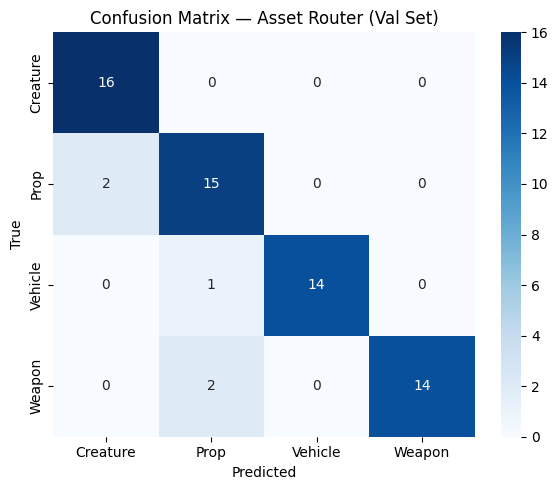

Confusion matrix saved.


In [7]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

results = trainer.evaluate()
print('\n=== Validation Results ===')
for k, v in results.items():
    print(f'  {k}: {v:.4f}')

# --- Full classification report ---
preds_out = trainer.predict(val_dataset)
preds     = np.argmax(preds_out.predictions, axis=1)
true      = preds_out.label_ids

print('\n=== Classification Report ===')
print(classification_report(true, preds, target_names=LABELS))

# --- Confusion matrix ---
cm = confusion_matrix(true, preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=LABELS,
            yticklabels=LABELS, cmap='Blues')
plt.title('Confusion Matrix — Asset Router (Val Set)')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/router_confusion_matrix.png', dpi=150)
plt.show()
print('Confusion matrix saved.')

## Step 8 — Save Checkpoint to Google Drive

In [8]:
import shutil

# Save model + tokenizer
SAVE_PATH = f'{CHECKPOINT_DIR}/distilbert_router_v1'
trainer.save_model(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)

# Save label map
import json
with open(f'{SAVE_PATH}/label_map.json', 'w') as f:
    json.dump({'label2id': LABEL2ID, 'id2label': ID2LABEL}, f, indent=2)

print(f'Model saved to: {SAVE_PATH}')
print(f'Files:')
for fn in os.listdir(SAVE_PATH):
    size = os.path.getsize(f'{SAVE_PATH}/{fn}') // 1024
    print(f'  {fn:40s} {size:>6} KB')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: /content/drive/MyDrive/GameForge3D/checkpoints/router/distilbert_router_v1
Files:
  config.json                                   0 KB
  model.safetensors                        261561 KB
  training_args.bin                             5 KB
  tokenizer_config.json                         0 KB
  tokenizer.json                              694 KB
  label_map.json                                0 KB


## Step 9 — Quick Inference Test

Test the trained router with sample prompts.

In [9]:
from transformers import pipeline

classifier = pipeline(
    'text-classification',
    model=SAVE_PATH,
    tokenizer=SAVE_PATH,
    device=0 if torch.cuda.is_available() else -1
)

TEST_PROMPTS = [
    'a flaming battle axe with runes',
    'a futuristic hover car',
    'a dragon breathing fire',
    'a wooden barrel with iron bands',
    'a magic wand with glowing tip',
    'a pirate ship with black sails',
    'a zombie rising from the grave',
    'an ancient stone altar'
]

print('=== Inference Test ===')
print(f'{"Prompt":<45} {"Predicted":<12} {"Score"}')
print('-' * 70)
for prompt in TEST_PROMPTS:
    result = classifier(prompt)[0]
    label  = result['label']
    score  = result['score']
    print(f'{prompt:<45} {label:<12} {score:.3f}')

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

=== Inference Test ===
Prompt                                        Predicted    Score
----------------------------------------------------------------------
a flaming battle axe with runes               Weapon       0.928
a futuristic hover car                        Vehicle      0.938
a dragon breathing fire                       Creature     0.861
a wooden barrel with iron bands               Prop         0.928
a magic wand with glowing tip                 Weapon       0.717
a pirate ship with black sails                Vehicle      0.891
a zombie rising from the grave                Creature     0.937
an ancient stone altar                        Prop         0.928


## Phase 2 Complete! ✅

| Output | Location |
|--------|----------|
| Trained Router Model | `checkpoints/router/distilbert_router_v1/` |
| Tokenizer | `checkpoints/router/distilbert_router_v1/` |
| Label Map | `checkpoints/router/distilbert_router_v1/label_map.json` |
| Confusion Matrix | `data/router_confusion_matrix.png` |

**Next → Phase 3: 3D Shape Generator (Shap-E style)**